In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

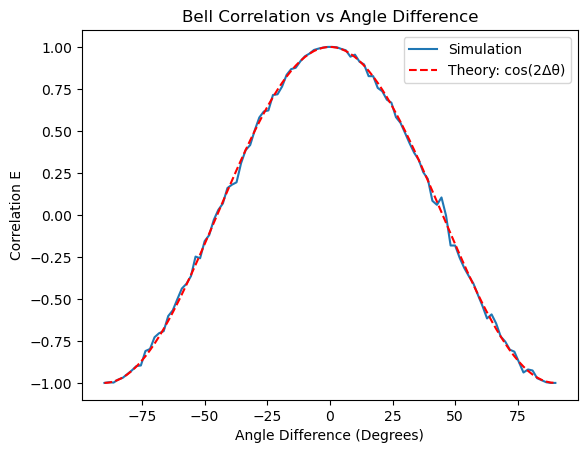

In [4]:
theta_1 = 0.0
theta_2 = np.linspace(-90,90,100)
correlation=[]
delta_angle=[]

simulator=AerSimulator()
shots=1000

def Bell(theta_1,theta_2,simulator,shots=shots,verbose=False):
    theta_1 = (np.pi/180)*theta_1
    theta_2 = (np.pi/180)*theta_2

    
    qc=QuantumCircuit(2,2)
    qc.h(0)
    qc.cx(0,1)
    qc.ry(-2*theta_1,0)
    qc.ry(-2*theta_2,1)
    qc.measure(0,0)
    qc.measure(1,1)
    
    counts=simulator.run(qc,shots=shots,).result().get_counts()
    
    N00=counts.get('00',0)
    N01=counts.get('01',0)
    N10=counts.get('10',0)
    N11=counts.get('11',0)
    
    E=(N00+N11-N01-N10)/shots
   
    if verbose:
        print(f'Value of E= {E:.4f}')
    return E



for i in theta_2:
    delta_angle.append(i-theta_1)
    correlation.append(Bell(theta_1,i,simulator))
E_theory = np.cos(2 * np.radians(theta_2 - theta_1))   
plt.plot(delta_angle, correlation, label='Simulation')
plt.plot(delta_angle, E_theory, 'r--', label='Theory: cos(2Δθ)')
plt.xlabel('Angle Difference (Degrees)')
plt.ylabel('Correlation E')
plt.title('Bell Correlation vs Angle Difference')
plt.legend()
plt.savefig("bell_correlation_vs_angle.png", dpi=150, bbox_inches='tight')
plt.show()